# UAS Bengkod
### Danendra Farrel Haryo Wibowo
### A11.2023.15025

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Tema visualisasi
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

# --- Library untuk Direct Modeling ---
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print('Library berhasil diimport!')

Library berhasil diimport!


## Load Dataset

> [Sales and Marketing Dataset](https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset)

In [ ]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')  # <-- SESUAIKAN NAMA FILE

print(f'Dataset berhasil dimuat!')
print(f'   Jumlah baris    : {df.shape[0]:,}')
print(f'   Jumlah kolom    : {df.shape[1]}')

Dataset berhasil dimuat!
   Jumlah baris    : 15,000
   Jumlah kolom    : 30


---
# EDA

## Nampilin 5 Baris Pertama, Info Dataset, dan Statistik Deskriptif

### 1.1 Lima Baris Pertama Dataset

In [ ]:
print('=== 5 BARIS PERTAMA DATASET ===')
df.head()

=== 5 BARIS PERTAMA DATASET ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,coupon_code,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0000,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,1,7,13.9037,5.4152,0.6700,0.2600,559.5250,65.2467,0,NEW20,0,0,3,UPI,3.0000,10,27.5600,915.3108,14,0
1,10002,NaN,35.0000,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,0,19,5.1125,5.3524,0.7000,0.3700,356.4913,48.4739,1,NEW20,5,0,3,BKash,3.0000,7,15.1500,2079.9609,11,0
2,10003,Female,27.0000,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,1,18,9.7427,3.5947,0.4700,0.4400,689.3322,77.8154,0,NaN,1,0,2,UPI,5.0000,6,13.5100,1379.1509,9,0
3,10004,Female,36.0000,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,1,16,9.6427,2.9495,0.5800,0.3700,445.4296,71.7122,0,NaN,0,0,2,PayPal,4.0000,6,25.6500,774.6527,7,0
4,10005,Male,29.0000,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,0,12,7.7913,2.4055,0.0500,0.1600,686.2860,44.9902,1,NaN,2,1,4,BKash,3.0000,1,12.3900,87.6804,11,0


### 1.2 Informasi Dataset

In [ ]:
print('=== INFORMASI DATASET ===')
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages

In [ ]:
print('=== RINGKASAN TIPE DATA ===')
dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Tipe Data', 'Jumlah Kolom']
print(dtype_summary.to_string(index=False))

=== RINGKASAN TIPE DATA ===
Tipe Data  Jumlah Kolom
    int64            10
   object            10
  float64            10


### 1.3 Statistik Deskriptif

In [ ]:
print('=== STATISTIK DESKRIPTIF — FITUR NUMERIK ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== STATISTIK DESKRIPTIF — FITUR NUMERIK ===


,count,mean,std,min,25%,50%,75%,max
customer_id,15000.000000,17500.500000,4330.271354,10001.000000,13750.750000,17500.500000,21250.250000,25000.000000
age,13800.000000,35.203913,10.334384,-4.000000,28.000000,35.000000,42.000000,95.000000
is_premium_user,15000.000000,0.304467,0.460197,0.000000,0.000000,0.000000,1.000000,1.000000
total_visits,15000.000000,15.000933,3.892704,3.000000,12.000000,15.000000,18.000000,31.000000
avg_session_time,15000.000000,8.020805,2.991499,0.006095,5.974555,7.991907,10.059986,19.123716
pages_per_session,15000.000000,4.002901,1.479846,0.007845,2.989150,3.996992,5.014406,10.843172
email_open_rate,15000.000000,0.496278,0.290108,0.000000,0.240000,0.500000,0.750000,1.000000
email_click_rate,15000.000000,0.251231,0.144689,0.000000,0.130000,0.250000,0.380000,0.500000
total_spent,13950.000000,524.357397,467.050070,0.267291,300.432074,498.843859,702.396635,15910.431879
avg_order_value,15000.000000,60.080882,24.746203,0.071596,43.032470,60.108827,76.888445,154.554696


In [ ]:
print('=== STATISTIK DESKRIPTIF — FITUR KATEGORIKAL ===')
df.describe(include='object')

=== STATISTIK DESKRIPTIF — FITUR KATEGORIKAL ===


,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


## Persentase Missing Value & Visualisasi Diagram Batang

In [ ]:
# Hitung jumlah dan persentase missing value
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Kolom'          : missing_count.index,
    'Jumlah Missing' : missing_count.values,
    'Persentase (%)'  : missing_pct.values
}).sort_values('Persentase (%)', ascending=False).reset_index(drop=True)

print('=== RINGKASAN MISSING VALUE ===')
print(f'Kolom tanpa missing value : {(missing_df["Jumlah Missing"] == 0).sum()}')
print(f'Kolom dengan missing value: {(missing_df["Jumlah Missing"] > 0).sum()}')
print()
print(missing_df[missing_df['Jumlah Missing'] > 0].to_string(index=False))

=== RINGKASAN MISSING VALUE ===
Kolom tanpa missing value : 25
Kolom dengan missing value: 5

             Kolom  Jumlah Missing  Persentase (%)
       coupon_code            6133         40.8867
               age            1200          8.0000
       total_spent            1050          7.0000
            gender             738          4.9200
satisfaction_score             702          4.6800


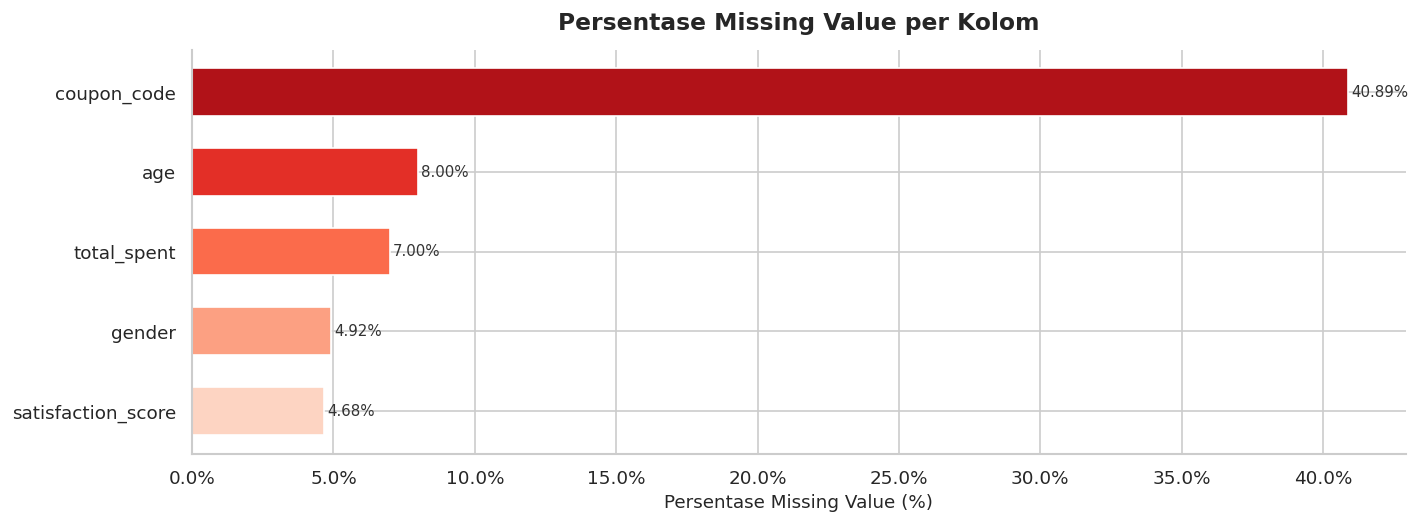


Grafik missing value berhasil ditampilkan.


In [ ]:
# Filter hanya kolom yang memiliki missing value
missing_plot = missing_df[missing_df['Jumlah Missing'] > 0].copy()

if missing_plot.empty:
    print('Tidak ada missing value pada dataset ini.')
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(missing_plot) * 0.5 + 2)))

    bars = ax.barh(
        missing_plot['Kolom'],
        missing_plot['Persentase (%)'],
        color=sns.color_palette('Reds_r', len(missing_plot)),
        edgecolor='white',
        height=0.6
    )

    for bar, val in zip(bars, missing_plot['Persentase (%)']):
        ax.text(
            bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, color='#333333'
        )

    ax.set_xlabel('Persentase Missing Value (%)', fontsize=11)
    ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold', pad=12)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('missing_value_chart.png', bbox_inches='tight')
    plt.show()
    print('\nGrafik missing value berhasil ditampilkan.')

---
## Distribusi Variabel Target

In [ ]:
# Hitung distribusi Churn
churn_counts = df['churn'].value_counts().sort_index()
churn_pct    = df['churn'].value_counts(normalize=True).sort_index() * 100

churn_summary = pd.DataFrame({
    'Label'     : ['Tidak Churn (0)', 'Churn (1)'],
    'Jumlah'    : churn_counts.values,
    'Persentase': churn_pct.values
})

print('=== DISTRIBUSI VARIABEL TARGET — CHURN ===')
print(churn_summary.to_string(index=False))

ratio = churn_counts[0] / churn_counts[1]
print(f'\nRasio kelas (Tidak Churn : Churn) = {ratio:.2f} : 1')
if ratio > 1.5:
    print('Dataset kemungkinan mengalami class imbalance.')
else:
    print('Dataset relatif seimbang.')

=== DISTRIBUSI VARIABEL TARGET — CHURN ===
          Label  Jumlah  Persentase
Tidak Churn (0)   12702     84.6800
      Churn (1)    2298     15.3200

Rasio kelas (Tidak Churn : Churn) = 5.53 : 1
Dataset kemungkinan mengalami class imbalance.


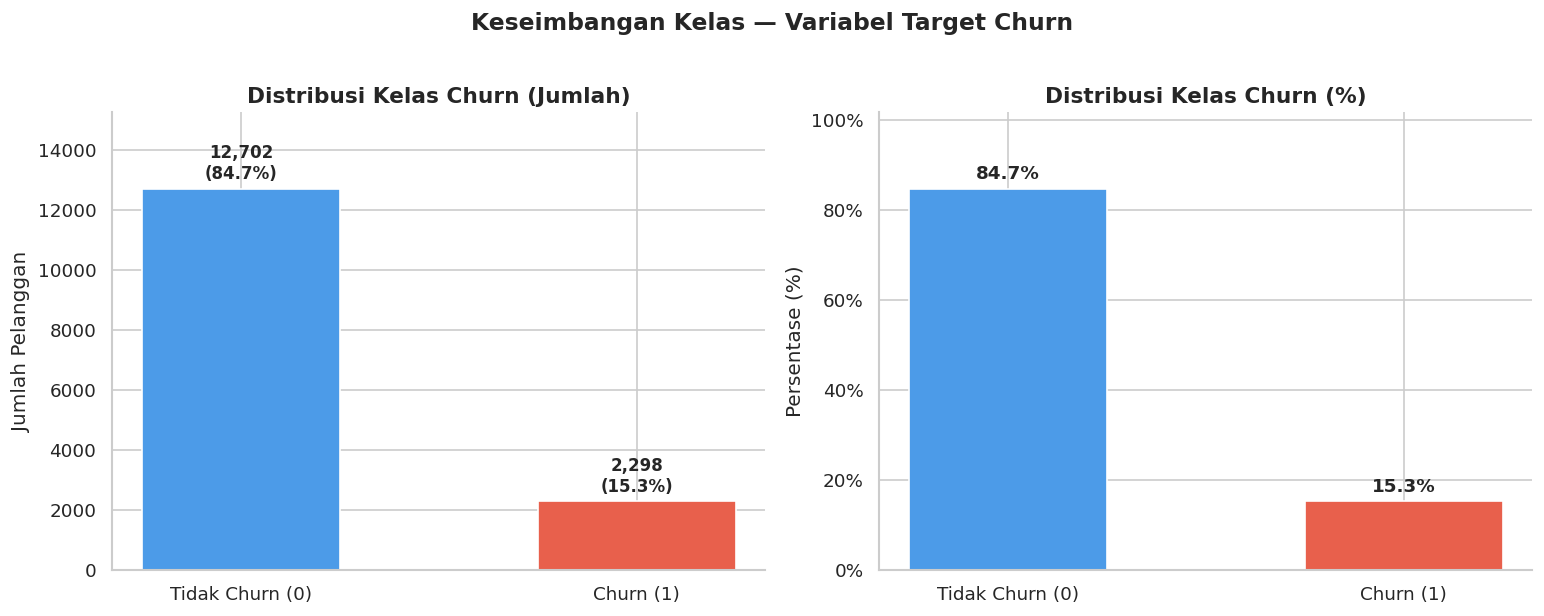


Grafik distribusi Churn berhasil ditampilkan.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = ['Tidak Churn (0)', 'Churn (1)']
colors   = ['#4C9BE8', '#E8604C']
counts   = churn_counts.values
percents = churn_pct.values

# --- Plot kiri: Diagram batang jumlah ---
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, counts, percents):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.015,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Distribusi Kelas Churn (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].spines[['top', 'right']].set_visible(False)

# --- Plot kanan: Diagram batang persentase ---
bars2 = axes[1].bar(labels, percents, color=colors, edgecolor='white', width=0.5)
for bar, pct in zip(bars2, percents):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percents) * 0.015,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Distribusi Kelas Churn (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_ylim(0, max(percents) * 1.2)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Keseimbangan Kelas — Variabel Target Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()
print('\nGrafik distribusi Churn berhasil ditampilkan.')

---
## Heatmap Korelasi Fitur Numerik

In [ ]:
# Pilih fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Jumlah fitur numerik: {len(numeric_cols)}')
print('Daftar fitur numerik:')
for col in numeric_cols:
    print(f'  - {col}')

Jumlah fitur numerik: 20
Daftar fitur numerik:
  - customer_id
  - age
  - is_premium_user
  - total_visits
  - avg_session_time
  - pages_per_session
  - email_open_rate
  - email_click_rate
  - total_spent
  - avg_order_value
  - discount_used
  - support_tickets
  - refund_requested
  - delivery_delay_days
  - satisfaction_score
  - nps_score
  - marketing_spend_per_user
  - lifetime_value
  - last_3_month_purchase_freq
  - churn


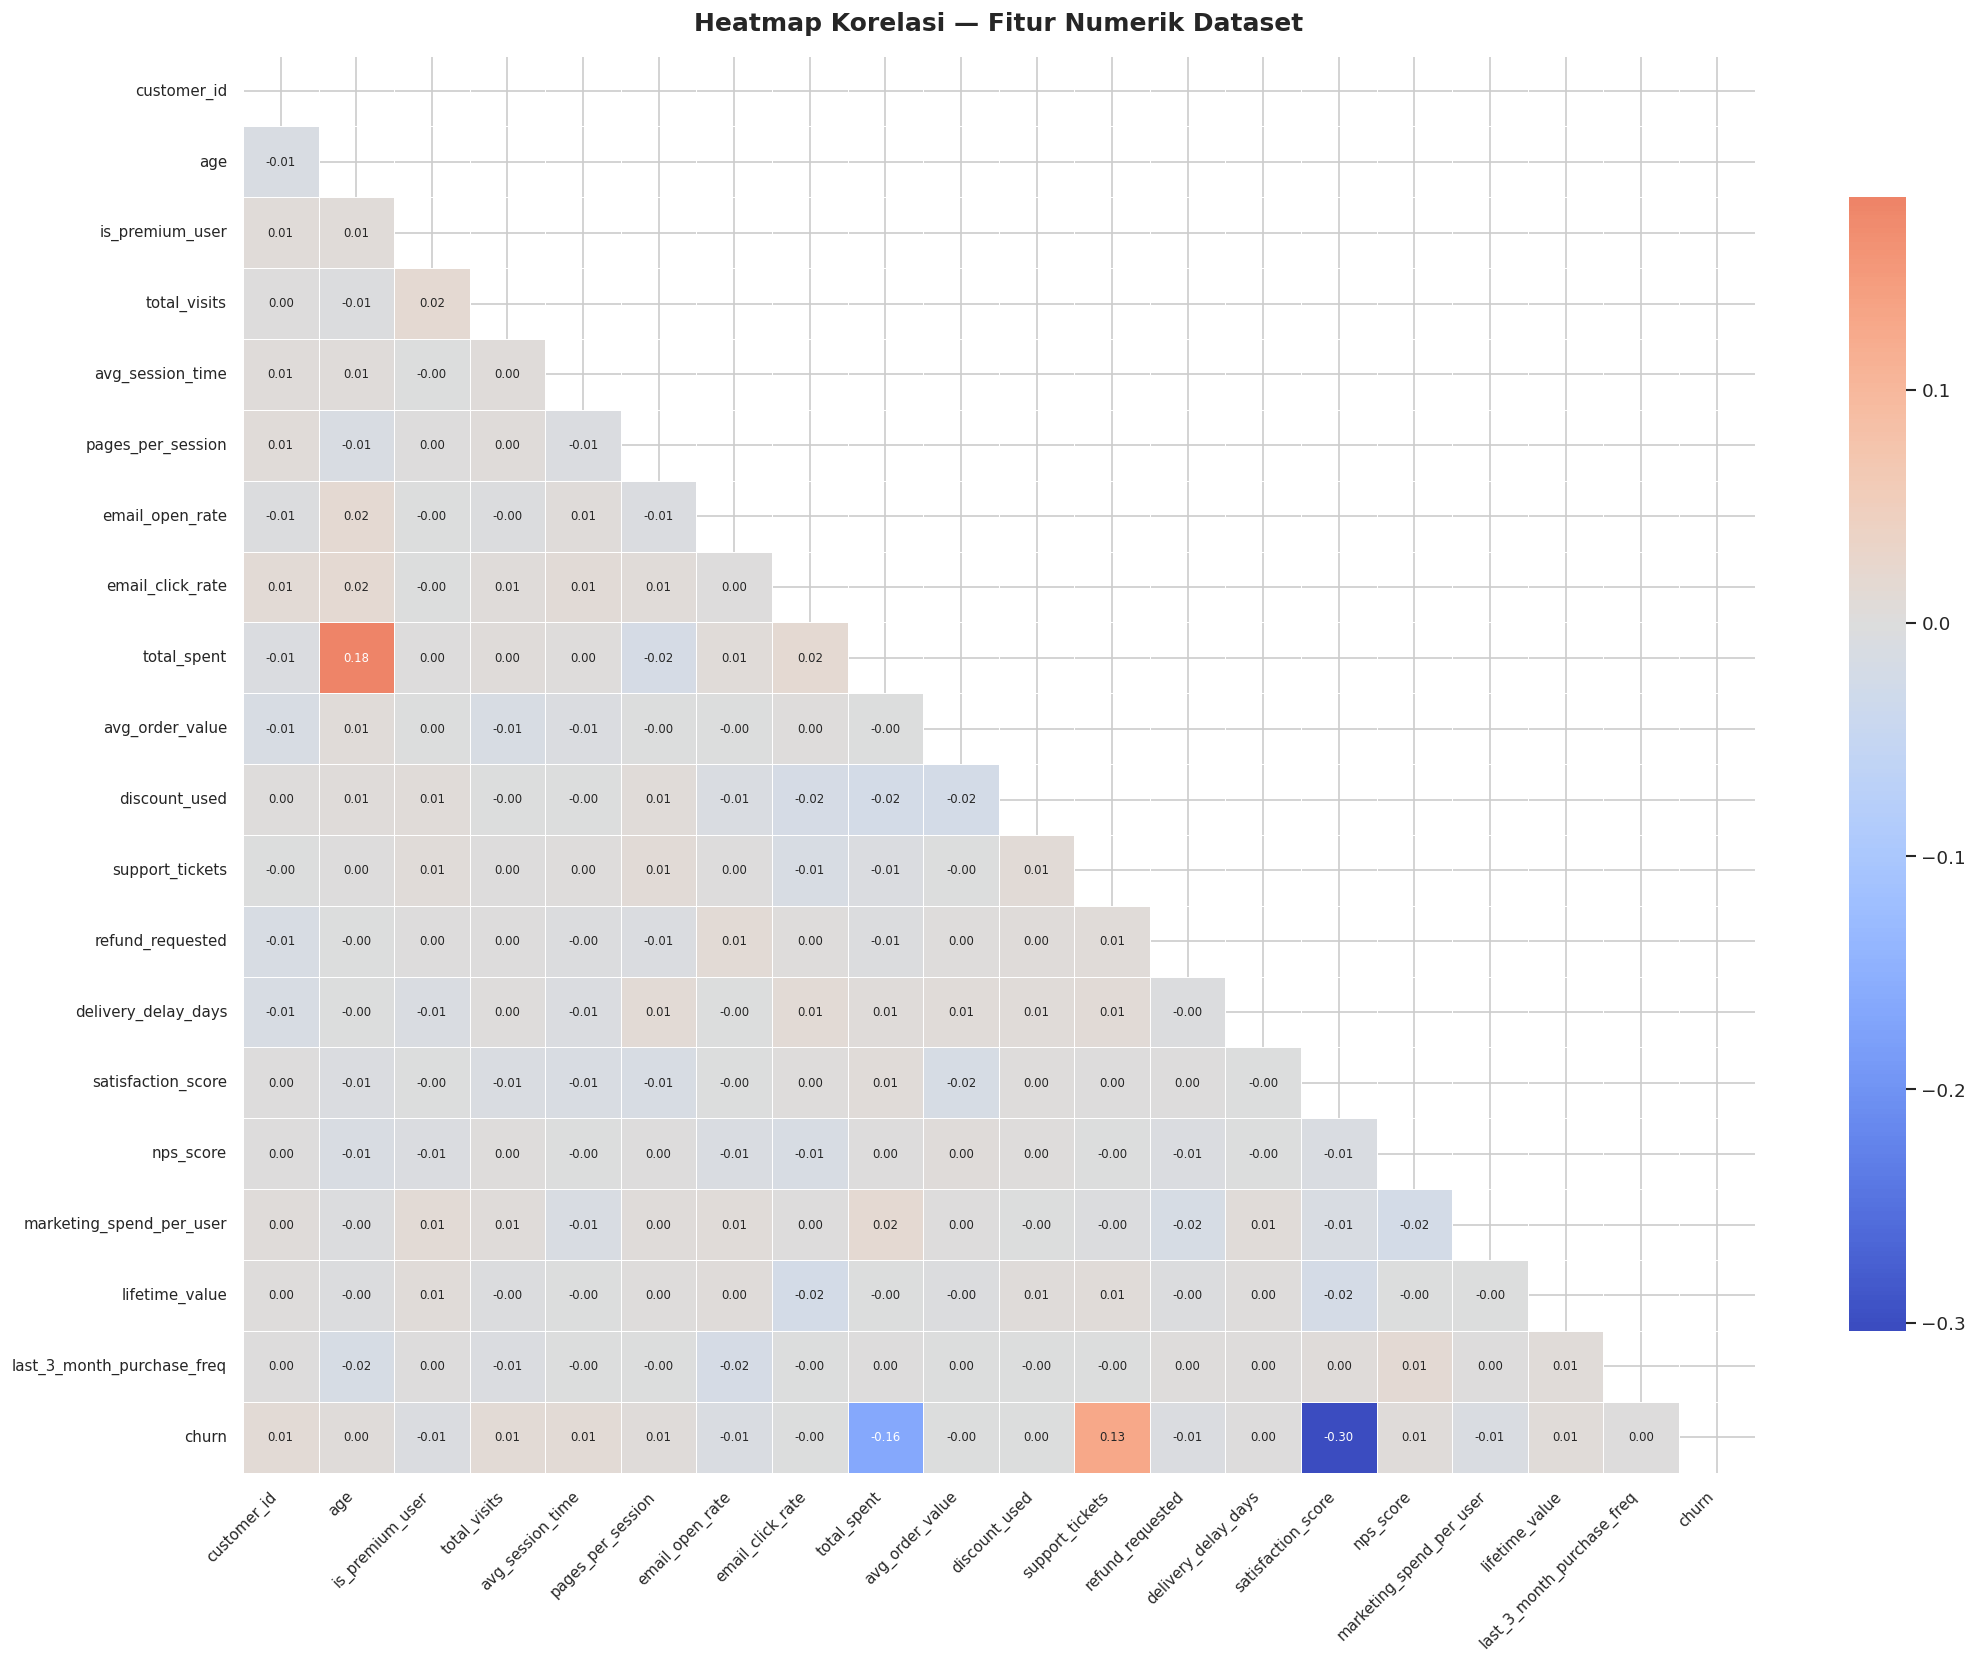


Heatmap korelasi berhasil ditampilkan.


In [ ]:
# Hitung matriks korelasi
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Heatmap Korelasi — Fitur Numerik Dataset', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('\nHeatmap korelasi berhasil ditampilkan.')

In [ ]:
# Korelasi fitur terhadap variabel target 'churn'
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

print('=== KORELASI FITUR NUMERIK TERHADAP CHURN (diurutkan dari tertinggi) ===')
churn_corr_df = pd.DataFrame({
    'Fitur'        : churn_corr.index,
    'Korelasi'     : churn_corr.values,
    'Abs Korelasi' : churn_corr.abs().values
})
print(churn_corr_df.to_string(index=False))

=== KORELASI FITUR NUMERIK TERHADAP CHURN (diurutkan dari tertinggi) ===
                     Fitur  Korelasi  Abs Korelasi
        satisfaction_score   -0.3036        0.3036
               total_spent   -0.1633        0.1633
           support_tickets    0.1279        0.1279
              total_visits    0.0132        0.0132
               customer_id    0.0122        0.0122
          avg_session_time    0.0122        0.0122
           email_open_rate   -0.0084        0.0084
  marketing_spend_per_user   -0.0073        0.0073
          refund_requested   -0.0070        0.0070
            lifetime_value    0.0063        0.0063
         pages_per_session    0.0059        0.0059
                 nps_score    0.0057        0.0057
           is_premium_user   -0.0055        0.0055
                       age    0.0045        0.0045
          email_click_rate   -0.0018        0.0018
       delivery_delay_days    0.0016        0.0016
last_3_month_purchase_freq    0.0016        0.0016
         

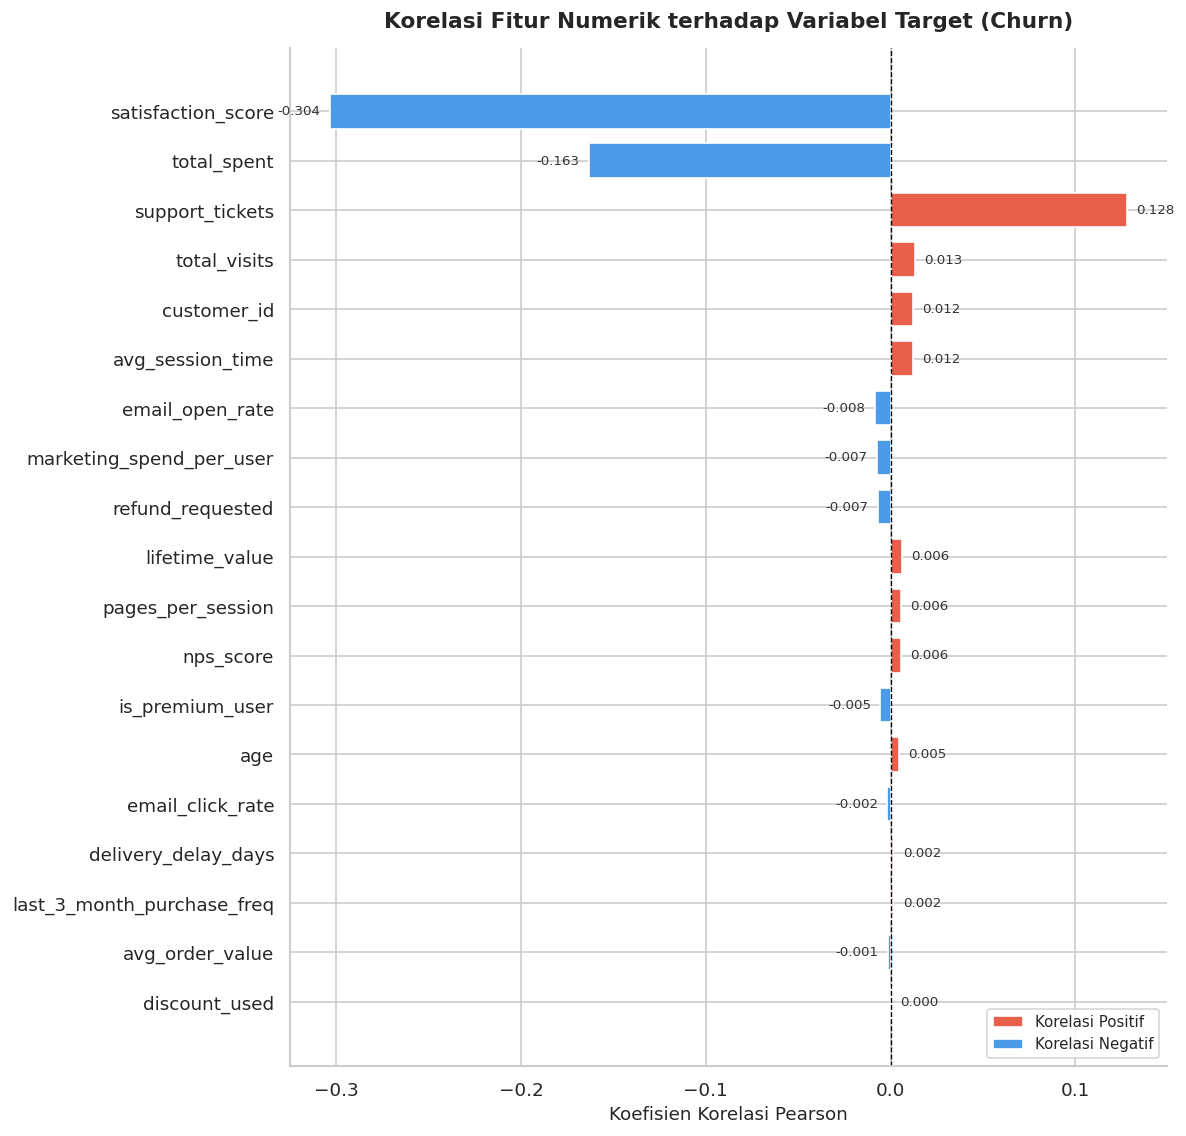


Grafik korelasi terhadap Churn berhasil ditampilkan.


In [ ]:
# Visualisasi korelasi terhadap Churn
fig, ax = plt.subplots(figsize=(10, max(5, len(churn_corr) * 0.4 + 2)))

colors_bar = ['#E8604C' if v > 0 else '#4C9BE8' for v in churn_corr.values]

bars = ax.barh(
    churn_corr.index,
    churn_corr.values,
    color=colors_bar,
    edgecolor='white',
    height=0.7
)

for bar, val in zip(bars, churn_corr.values):
    offset = 0.005 if val >= 0 else -0.005
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', ha=ha, fontsize=8, color='#333333'
    )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Koefisien Korelasi Pearson', fontsize=11)
ax.set_title('Korelasi Fitur Numerik terhadap Variabel Target (Churn)',
             fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8604C', label='Korelasi Positif'),
    Patch(facecolor='#4C9BE8', label='Korelasi Negatif')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('churn_correlation_bar.png', bbox_inches='tight')
plt.show()
print('\nGrafik korelasi terhadap Churn berhasil ditampilkan.')

In [ ]:
# Identifikasi hubungan antar variabel yang berpotensi mempengaruhi Churn
threshold   = 0.1
strong_corr = churn_corr_df[churn_corr_df['Abs Korelasi'] >= threshold].copy()

print(f'=== FITUR DENGAN KORELASI >= {threshold} TERHADAP CHURN ===')
if strong_corr.empty:
    print(f'Tidak ada fitur dengan korelasi >= {threshold}.')
    print('Gunakan threshold lebih kecil atau pertimbangkan analisis non-linear.')
else:
    for _, row in strong_corr.iterrows():
        direction = 'positif' if row['Korelasi'] > 0 else 'negatif'
        print(f"  {row['Fitur']:<35} | r = {row['Korelasi']:+.4f} | {direction}")

print('\nInterpretasi:')
print('  r > 0 : fitur naik, kemungkinan churn naik (risiko lebih tinggi)')
print('  r < 0 : fitur naik, kemungkinan churn turun (lebih loyal)')

=== FITUR DENGAN KORELASI >= 0.1 TERHADAP CHURN ===
  satisfaction_score                  | r = -0.3036 | negatif
  total_spent                         | r = -0.1633 | negatif
  support_tickets                     | r = +0.1279 | positif

Interpretasi:
  r > 0 : fitur naik, kemungkinan churn naik (risiko lebih tinggi)
  r < 0 : fitur naik, kemungkinan churn turun (lebih loyal)


---
## Ringkasan Temuan EDA

| Aspek | Temuan |
|---|---|
| **Jumlah Data** | 15.000 records, 30 kolom |
| **Missing Value** | Lihat output di atas |
| **Keseimbangan Kelas** | Lihat output distribusi churn |
| **Fitur Berkorelasi dengan Churn** | Lihat output heatmap korelasi |

---
# Direct Modeling


## Persiapan Data
> Karena scikit-learn tidak dapat membaca kolom bertipe `object`, dilakukan **Label Encoding minimal** agar data bisa diproses model. Ini bukan preprocessing penuh — tidak ada scaling, tidak ada feature engineering.

In [ ]:
df_direct = df.copy()

# Tangani missing value secara minimal
for col in df_direct.columns:
    if df_direct[col].isnull().sum() > 0:
        if df_direct[col].dtype == 'object':
            df_direct[col].fillna(df_direct[col].mode()[0], inplace=True)
        else:
            df_direct[col].fillna(df_direct[col].median(), inplace=True)

# Label Encoding untuk kolom kategorikal
le       = LabelEncoder()
cat_cols = df_direct.select_dtypes(include='object').columns.tolist()

print(f'Kolom kategorikal yang di-encode ({len(cat_cols)} kolom):')
for col in cat_cols:
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))
    print(f'  - {col}')

# Hapus kolom ID
if 'customer_id' in df_direct.columns:
    df_direct.drop(columns=['customer_id'], inplace=True)
    print('\nKolom customer_id dihapus.')

print(f'\nShape data setelah persiapan: {df_direct.shape}')

Kolom kategorikal yang di-encode (10 kolom):
  - gender
  - country
  - city
  - signup_date
  - last_purchase_date
  - acquisition_channel
  - device_type
  - subscription_type
  - coupon_code
  - payment_method

Kolom customer_id dihapus.

Shape data setelah persiapan: (15000, 29)


## Menetapkan Variabel Target (y) dan Fitur Prediktor (X)

In [ ]:
TARGET = 'churn'

X = df_direct.drop(columns=[TARGET])
y = df_direct[TARGET]

print('=== VARIABEL PREDIKTOR (X) DAN TARGET (y) ===')
print(f'Jumlah fitur prediktor (X) : {X.shape[1]}')
print(f'Jumlah sampel              : {X.shape[0]:,}')
print(f'Variabel target (y)        : "{TARGET}"')
print()
print('Distribusi variabel target:')
for label, count in y.value_counts().sort_index().items():
    ket = 'Tidak Churn' if label == 0 else 'Churn'
    print(f'  {label} ({ket}) : {count:,}  ({count/len(y)*100:.2f}%)')
print()
print('Daftar fitur (X):')
print(list(X.columns))

=== VARIABEL PREDIKTOR (X) DAN TARGET (y) ===
Jumlah fitur prediktor (X) : 28
Jumlah sampel              : 15,000
Variabel target (y)        : "churn"

Distribusi variabel target:
  0 (Tidak Churn) : 12,702  (84.68%)
  1 (Churn) : 2,298  (15.32%)

Daftar fitur (X):
['gender', 'age', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


## Train–Test Split

In [ ]:
TEST_SIZE   = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_SEED,
    stratify     = y
)

print('=== HASIL TRAIN–TEST SPLIT ===')
print(f'Total data       : {len(X):,}')
print(f'Data latih (80%) : {len(X_train):,}')
print(f'Data uji  (20%)  : {len(X_test):,}')
print()
print('Distribusi kelas — data latih:')
for label, count in y_train.value_counts().sort_index().items():
    print(f'  Kelas {label} : {count:,}  ({count/len(y_train)*100:.2f}%)')
print()
print('Distribusi kelas — data uji:')
for label, count in y_test.value_counts().sort_index().items():
    print(f'  Kelas {label} : {count:,}  ({count/len(y_test)*100:.2f}%)')

=== HASIL TRAIN–TEST SPLIT ===
Total data       : 15,000
Data latih (80%) : 12,000
Data uji  (20%)  : 3,000

Distribusi kelas — data latih:
  Kelas 0 : 10,162  (84.68%)
  Kelas 1 : 1,838  (15.32%)

Distribusi kelas — data uji:
  Kelas 0 : 2,540  (84.67%)
  Kelas 1 : 460  (15.33%)


## Definisi Tiga Model Machine Learning

In [ ]:
# Model 1 — Konvensional: Logistic Regression
model_lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)

# Model 2 — Ensemble Bagging: Random Forest
model_rf = RandomForestClassifier(random_state=RANDOM_SEED)

# Model 3 — Ensemble Voting: Logistic Regression + SVM + KNN
base_lr  = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
base_svm = SVC(probability=True, random_state=RANDOM_SEED)
base_knn = KNeighborsClassifier()

model_voting = VotingClassifier(
    estimators=[('lr', base_lr), ('svm', base_svm), ('knn', base_knn)],
    voting='soft'
)

models = {
    'Logistic Regression'           : model_lr,
    'Random Forest'                 : model_rf,
    'Voting Classifier (LR+SVM+KNN)': model_voting
}

print('=== DAFTAR MODEL ===')
info = [
    ('1', 'Logistic Regression'           , 'Konvensional'    ),
    ('2', 'Random Forest'                 , 'Ensemble Bagging'),
    ('3', 'Voting Classifier (LR+SVM+KNN)', 'Ensemble Voting' ),
]
for no, nama, kategori in info:
    print(f'  {no}. {nama:<40} | {kategori}')

=== DAFTAR MODEL ===
  1. Logistic Regression                      | Konvensional
  2. Random Forest                            | Ensemble Bagging
  3. Voting Classifier (LR+SVM+KNN)           | Ensemble Voting


## Pelatihan Model
> Tanpa preprocessing & tanpa hyperparameter tuning.

In [ ]:
trained_models = {}
training_times = {}

print('=== MELATIH MODEL ===')
for name, model in models.items():
    print(f'Melatih: {name} ...', end=' ', flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    training_times[name] = elapsed
    print(f'selesai ({elapsed:.2f} detik)')

print('\nSemua model berhasil dilatih!')

=== MELATIH MODEL ===
Melatih: Logistic Regression ... selesai (1.75 detik)
Melatih: Random Forest ... selesai (3.40 detik)
Melatih: Voting Classifier (LR+SVM+KNN) ... selesai (36.75 detik)

Semua model berhasil dilatih!


## Evaluasi Performa Model

###- Tabel Metrik Evaluasi

In [ ]:
results = []
preds   = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score (y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score   (y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score       (y_test, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results).set_index('Model')

print('=== RINGKASAN METRIK EVALUASI — DIRECT MODELING ===')
print(results_df.round(4).to_string())

=== RINGKASAN METRIK EVALUASI — DIRECT MODELING ===
                                Accuracy  Precision  Recall  F1-Score
Model                                                                
Logistic Regression               0.8463     0.4964  0.1478    0.2278
Random Forest                     0.8507     0.5213  0.3196    0.3962
Voting Classifier (LR+SVM+KNN)    0.8467     0.5000  0.0761    0.1321


In [ ]:
results_df.style \
    .format('{:.4f}') \
    .background_gradient(cmap='YlGn', axis=0) \
    .set_caption('Perbandingan Metrik Evaluasi — Direct Modeling') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold')]
    }])

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8463,0.4964,0.1478,0.2278
Random Forest,0.8507,0.5213,0.3196,0.3962
Voting Classifier (LR+SVM+KNN),0.8467,0.5000,0.0761,0.1321


###- Visualisasi Perbandingan Metrik

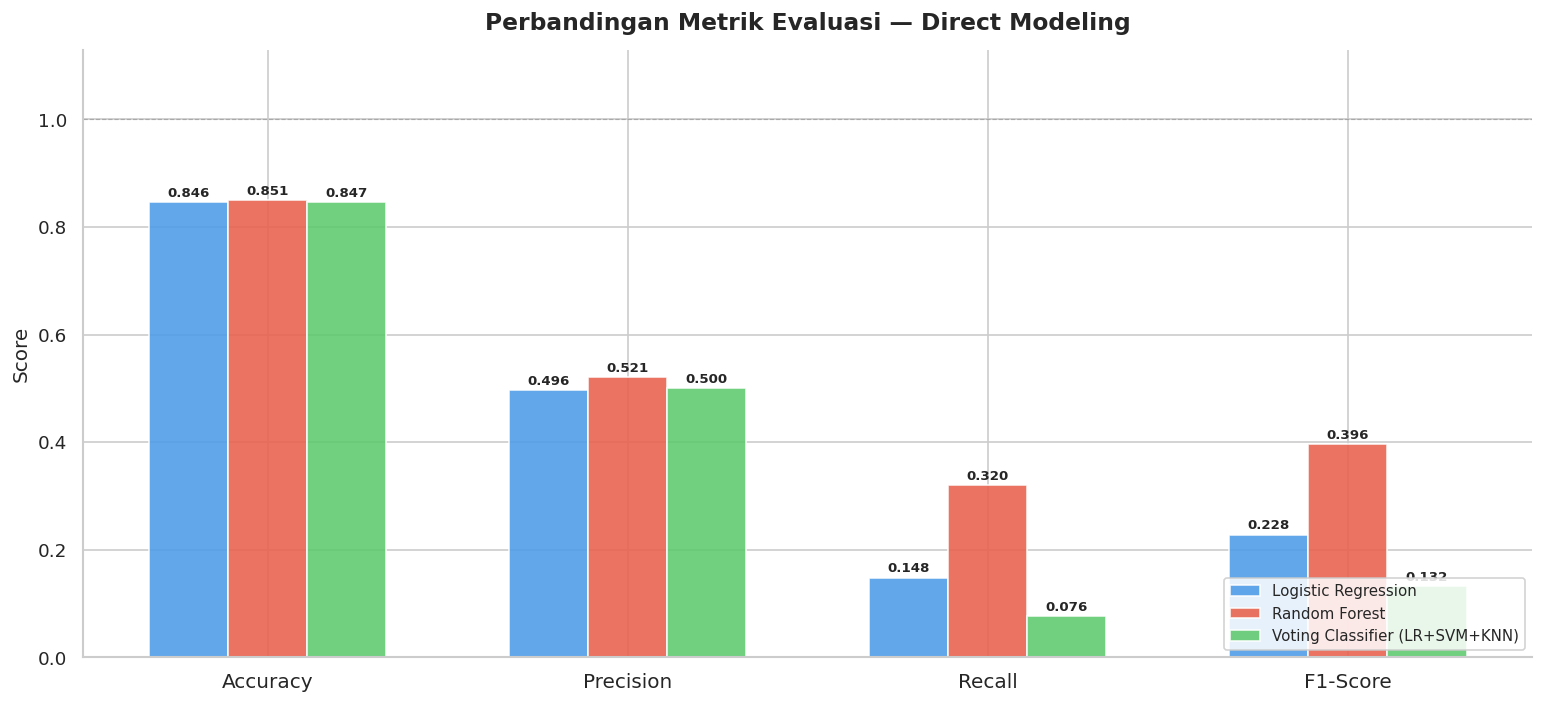

In [ ]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = results_df.index.tolist()
x           = np.arange(len(metrics))
bar_width   = 0.22
colors      = ['#4C9BE8', '#E8604C', '#5DC96E']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals   = results_df.loc[name, metrics].values
    offset = (i - 1) * bar_width
    bars   = ax.bar(x + offset, vals, bar_width,
                    label=name, color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.13)
ax.set_title('Perbandingan Metrik Evaluasi — Direct Modeling',
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.85)
ax.axhline(y=1.0, color='gray', linewidth=0.7, linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('direct_metrics_comparison.png', bbox_inches='tight')
plt.show()

###- Classification Report

In [ ]:
for name, y_pred in preds.items():
    print('=' * 55)
    print(f'  Classification Report: {name}')
    print('=' * 55)
    print(classification_report(
        y_test, y_pred,
        target_names=['Tidak Churn (0)', 'Churn (1)']
    ))

  Classification Report: Logistic Regression
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.97      0.91      2540
      Churn (1)       0.50      0.15      0.23       460

       accuracy                           0.85      3000
      macro avg       0.68      0.56      0.57      3000
   weighted avg       0.81      0.85      0.81      3000

  Classification Report: Random Forest
                 precision    recall  f1-score   support

Tidak Churn (0)       0.88      0.95      0.91      2540
      Churn (1)       0.52      0.32      0.40       460

       accuracy                           0.85      3000
      macro avg       0.70      0.63      0.66      3000
   weighted avg       0.83      0.85      0.84      3000

  Classification Report: Voting Classifier (LR+SVM+KNN)
                 precision    recall  f1-score   support

Tidak Churn (0)       0.85      0.99      0.92      2540
      Churn (1)       0.50      0.08      0.13       46

###- Confusion Matrix

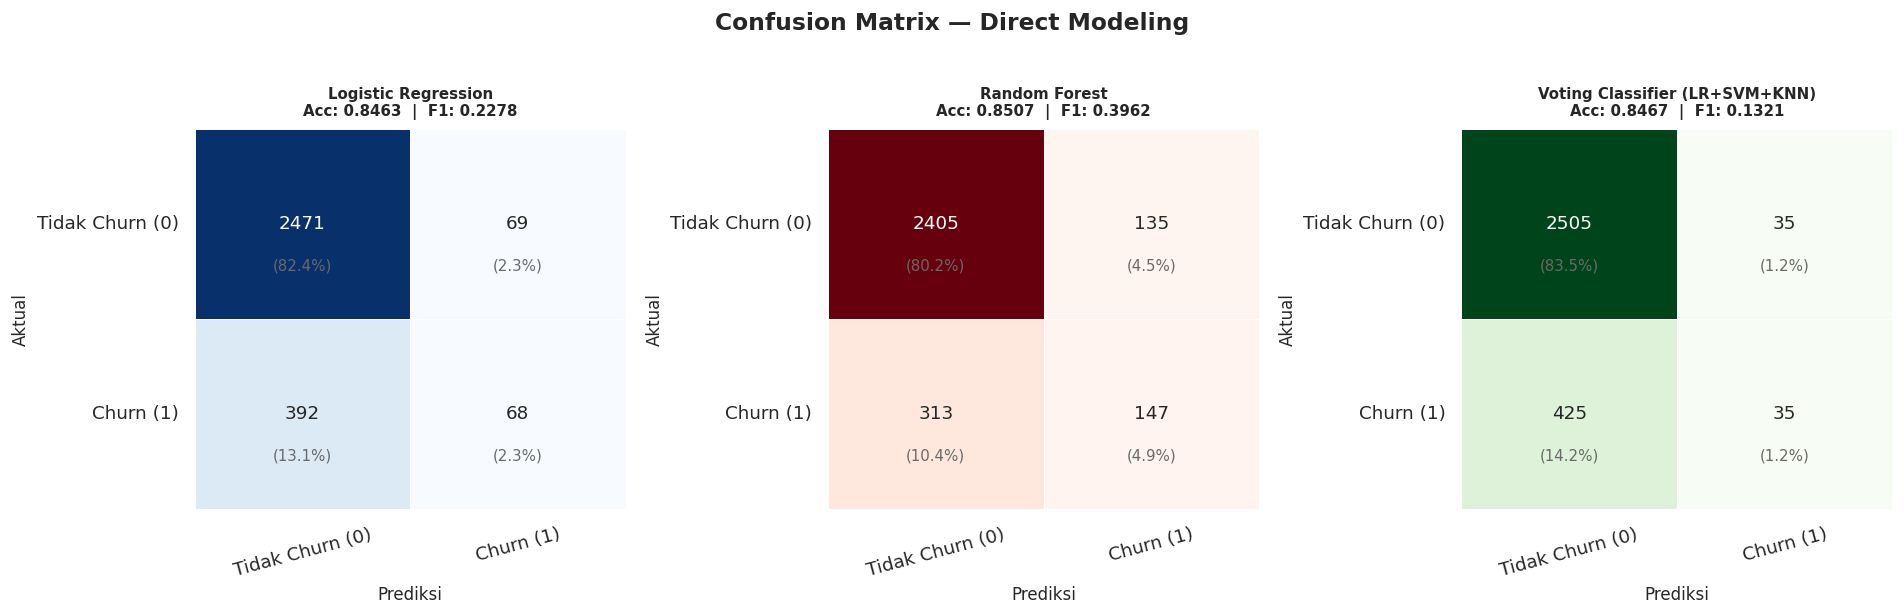

In [ ]:
fig, axes    = plt.subplots(1, 3, figsize=(16, 5))
class_labels = ['Tidak Churn (0)', 'Churn (1)']
cmap_list    = ['Blues', 'Reds', 'Greens']

for ax, (name, y_pred), cmap in zip(axes, preds.items(), cmap_list):
    cm    = confusion_matrix(y_test, y_pred)
    total = cm.sum()

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar=False
    )

    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5, i + 0.72,
                f'({cm[i,j]/total*100:.1f}%)',
                ha='center', va='center', fontsize=9, color='dimgray'
            )

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    ax.set_title(
        f'{name}\nAcc: {acc:.4f}  |  F1: {f1:.4f}',
        fontsize=9, fontweight='bold', pad=8
    )
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix — Direct Modeling',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('direct_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## Ringkasan Direct Modeling

In [ ]:
best_acc = results_df['Accuracy'].idxmax()
best_f1  = results_df['F1-Score'].idxmax()
best_rec = results_df['Recall'].idxmax()

print('=' * 58)
print('         RINGKASAN HASIL DIRECT MODELING')
print('=' * 58)
print(results_df[['Accuracy','Precision','Recall','F1-Score']]
      .applymap(lambda x: f'{x:.4f}').to_string())
print()
print(f'Model Accuracy tertinggi : {best_acc}')
print(f'  Accuracy = {results_df.loc[best_acc, "Accuracy"]:.4f}')
print()
print(f'Model F1-Score tertinggi : {best_f1}')
print(f'  F1-Score = {results_df.loc[best_f1, "F1-Score"]:.4f}')
print()
print(f'Model Recall tertinggi   : {best_rec}')
print(f'  Recall   = {results_df.loc[best_rec, "Recall"]:.4f}')
print()
print('Waktu pelatihan:')
for name, t in training_times.items():
    print(f'  {name:<40} : {t:.2f} detik')
print()
print('Catatan: Skenario ini dijalankan TANPA preprocessing')
print('dan TANPA hyperparameter tuning.')
print('Hasil akan dibandingkan pada skenario berikutnya:')
print('  -> Skenario 2: Modeling dengan Preprocessing')
print('  -> Skenario 3: Hyperparameter Tuning')
print('=' * 58)

         RINGKASAN HASIL DIRECT MODELING
                               Accuracy Precision  Recall F1-Score
Model                                                             
Logistic Regression              0.8463    0.4964  0.1478   0.2278
Random Forest                    0.8507    0.5213  0.3196   0.3962
Voting Classifier (LR+SVM+KNN)   0.8467    0.5000  0.0761   0.1321

Model Accuracy tertinggi : Random Forest
  Accuracy = 0.8507

Model F1-Score tertinggi : Random Forest
  F1-Score = 0.3962

Model Recall tertinggi   : Random Forest
  Recall   = 0.3196

Waktu pelatihan:
  Logistic Regression                      : 1.75 detik
  Random Forest                            : 3.40 detik
  Voting Classifier (LR+SVM+KNN)           : 36.75 detik

Catatan: Skenario ini dijalankan TANPA preprocessing
dan TANPA hyperparameter tuning.
Hasil akan dibandingkan pada skenario berikutnya:
  -> Skenario 2: Modeling dengan Preprocessing
  -> Skenario 3: Hyperparameter Tuning
